In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/DISCO_USECASES/

# verify the file is there
!ls -la

# import
from evaluation import Autoencoder, load_and_recover_z3d_png, infer_cell_map

Mounted at /content/drive
/content/drive/MyDrive/DISCO_USECASES
total 1966817
-rw------- 1 root root      12999 Oct  1 20:43 '20250916_Evaluation_for_GapFiller(cell composition trend).ipynb'
-rw------- 1 root root      17271 Oct  1 17:25  202509GapFiller.ipynb
drwx------ 2 root root       4096 Sep 10 20:55  202509GapFillerOldResults
-rw------- 1 root root      14740 Sep 10 21:04  202509Outpainting.py
drwx------ 2 root root       4096 Oct  1 18:30  20251001GapFillerColorGuidedResults
drwx------ 2 root root       4096 Sep 10 21:03  2025LongGeneration_Results
-rw------- 1 root root       8008 May  6 15:39  evaluation.py
drwx------ 2 root root       4096 Jul 20 04:47  merfish
-rw------- 1 root root    2705874 Jul 20 04:36  merfish_autoencoder_weights.pth
-rw------- 1 root root 2010902580 Jul 20 04:00  merfish_cell_embeddings.csv
-rw------- 1 root root      58131 Sep 10 20:58  MerFISHDiffusion.ipynb
-rw------- 1 root root     267877 Jul 20 21:55  merfish_processing.ipynb
-rw------- 1 root r

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

base_dir = "/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT"
model_path = "/content/drive/MyDrive/newae2.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

cell_type_names = [
    "B", "CD4+ T cell", "CD57+ Enterocyte", "CD66+ Enterocyte", "CD7+ Immune",
    "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
    "Goblet", "ICC", "Lymphatic", "M1 Macrophage", "M2 Macrophage",
    "MUC1+ Enterocyte", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
    "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
]

type_color_dict = {
    1: [134.9, 124.1, 8.7],
    2: [62.3, 216.0, 132.0],
    3: [130.9, 46.4, 182.5],
    4: [92.8, 63.6, 202.5],
    5: [140.1, 239.7, 189.0],
    6: [200.0, 183.1, 168.9],
    7: [108.3, 16.1, 142.3],
    8: [132.7, 217.1, 223.4],
    9: [170.6, 96.0, 98.0],
    10: [68.4, 101.1, 101.3],
    11: [4.6, 146.9, 145.6],
    12: [177.1, 1.5, 112.2],
    13: [202.6, 136.4, 12.3],
    14: [95.1, 244.3, 209.6],
    15: [32.5, 214.2, 217.8],
    16: [176.2, 78.6, 193.2],
    17: [185.9, 206.0, 77.8],
    18: [212.0, 39.3, 35.0],
    19: [117.1, 190.4, 53.4],
    20: [101.2, 145.2, 246.9],
    21: [13.7, 179.1, 133.2],
    22: [247.4, 125.5, 111.5],
    23: [122.9, 151.0, 150.0],
    24: [118.0, 45.6, 47.7],
    25: [31.1, 114.7, 222.5]
}

def compute_ratio_from_types(type_map: np.ndarray, num_types: int = 25) -> np.ndarray:
    a = type_map.astype(int)
    mask = (a >= 1) & (a <= num_types)
    if not np.any(mask):
        return np.zeros(num_types, dtype=float)
    a_fg = a[mask] - 1  # 0-based
    counts = np.bincount(a_fg.ravel(), minlength=num_types)
    ratio = counts / counts.sum()
    return ratio

@torch.no_grad()
def infer_distribution(img_path: str, model: torch.nn.Module, device: str = "cuda") -> np.ndarray:
    z3d = load_and_recover_z3d_png(img_path).to(device)
    pred_types = infer_cell_map(z3d, model)
    if isinstance(pred_types, torch.Tensor):
        pred_types = pred_types.squeeze().detach().cpu().numpy()
    return compute_ratio_from_types(pred_types, num_types=25)

def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def main():

    order_types = list(type_color_dict.keys())                           # e.g., [1,2,...,25] 但以字典写入顺序为准
    idx = np.array([t - 1 for t in order_types])                         # 0-based
    cell_type_names_ord = [cell_type_names[t - 1] for t in order_types]
    color_list_ord = [np.array(type_color_dict[t]) / 255.0 for t in order_types]

    model = Autoencoder().to(device)
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.eval()


    tissue_order = ["L"] + [str(i) for i in range(8)] + ["R"]
    path_map = {name: os.path.join(base_dir, f"{name}.png") for name in tissue_order}


    missing = [k for k, p in path_map.items() if not os.path.isfile(p)]
    if missing:
        raise FileNotFoundError(f"以下文件未找到：{missing}. 请检查 base_dir = {base_dir}")


    distributions = []
    for name in tissue_order:
        p = path_map[name]
        ratio = infer_distribution(p, model, device=device)
        distributions.append(ratio)
    distributions = np.stack(distributions, axis=0)  # (10, 25)


    distributions_ord = distributions[:, idx]         # (10, 25)


    x = np.arange(len(tissue_order))                  # 0..9
    y_values = distributions_ord.T                    # (25, 10)

    fig1, ax1 = plt.subplots(figsize=(16, 6))
    ax1.stackplot(
        x,
        *y_values,
        labels=cell_type_names_ord,
        colors=color_list_ord,
        alpha=0.9
    )
    ax1.set_xticks(x)
    ax1.set_xticklabels(tissue_order, rotation=0)
    ax1.set_ylim(0, 1.0)
    ax1.set_ylabel("Proportion")
    ax1.set_title("Cell Type Distribution Wave (L, 0–7, R)")

    leg1 = ax1.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=7,
        frameon=False,
        ncol=1
    )
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    ensure_dir(base_dir)
    wave_path = os.path.join(base_dir, "distribution_wave.png")
    plt.savefig(wave_path, dpi=300)
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(16, 6))
    bottoms = np.zeros(len(tissue_order), dtype=float)

    for i, (name_i, color_i) in enumerate(zip(cell_type_names_ord, color_list_ord)):
        vals = distributions_ord[:, i]  # (10,)
        ax2.bar(
            x,
            vals,
            bottom=bottoms,
            color=color_i,
            edgecolor='none',
            label=name_i,
            width=0.85
        )
        bottoms += vals

    ax2.set_xticks(x)
    ax2.set_xticklabels(tissue_order, rotation=0)
    ax2.set_ylim(0, 1.0)
    ax2.set_ylabel("Proportion")
    ax2.set_title("Cell Type Distribution (Stacked Bars) for L, 0–7, R")
    ax2.grid(axis='y', linestyle='--', alpha=0.25)

    leg2 = ax2.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=7,
        frameon=False,
        ncol=1
    )
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    bars_path = os.path.join(base_dir, "distribution_stacked_bars.png")
    plt.savefig(bars_path, dpi=300)
    plt.show()

    print(f"Saved:\n  {wave_path}\n  {bars_path}")


In [23]:
from PIL import Image
import os
from typing import List, Optional

def slice_image_vertical(
    input_path: str,
    output_dir: str,
    middle_count: int = 8,
    labels: Optional[List[str]] = None,
    overlap: int = 0,
    fmt: str = "PNG"
    ) -> List[str]:
    """
    Slice an image into vertical tiles and save as:
       L.png, 0.png..(middle_count-1).png, R.png  (default)
    or use custom `labels`.

    Args:
        input_path: path to source image.
        output_dir: folder to write tiles.
        middle_count: number of middle slices between L and R.
        labels: custom labels list (length = middle_count + 2).
                If None, uses ['L', '0', ..., str(middle_count-1), 'R'].
        overlap: extra pixels to include on the right edge of each slice
                 (except the last) to create overlapping tiles.
        fmt: image format to save (e.g., 'PNG').

    Returns:
        List of saved file paths in order of labels.
    """
    os.makedirs(output_dir, exist_ok=True)

    img = Image.open(input_path).convert("RGB")
    w, h = img.size

    if labels is None:
        labels = ["L"] + [str(i) for i in range(middle_count)] + ["R"]
    assert len(labels) == middle_count + 2, "labels must be middle_count + 2 long"

    num_slices = len(labels)

    # Equal widths; distribute remainder to the first slices
    base_slice_w = w // num_slices
    remainder = w % num_slices
    slice_widths = [base_slice_w + (1 if i < remainder else 0) for i in range(num_slices)]

    saved = []
    x = 0
    for i, (label, sw) in enumerate(zip(labels, slice_widths)):
        # Add overlap to all but the last slice
        right = x + sw + (overlap if i < num_slices - 1 else 0)
        right = min(right, w)
        box = (x, 0, right, h)
        tile = img.crop(box)
        out_path = os.path.join(output_dir, f"{label}.png")
        tile.save(out_path, fmt)
        saved.append(out_path)
        x += sw  # move by the base width (not including overlap)
    return saved


paths = slice_image_vertical(
    input_path="/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/fillresult/pair_2_4_leftright_1200.png",
    output_dir="/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT",
    middle_count=8
)
print(paths)


['/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/L.png', '/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/0.png', '/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/1.png', '/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/2.png', '/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/3.png', '/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/4.png', '/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/5.png', '/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/6.png', '/content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftr

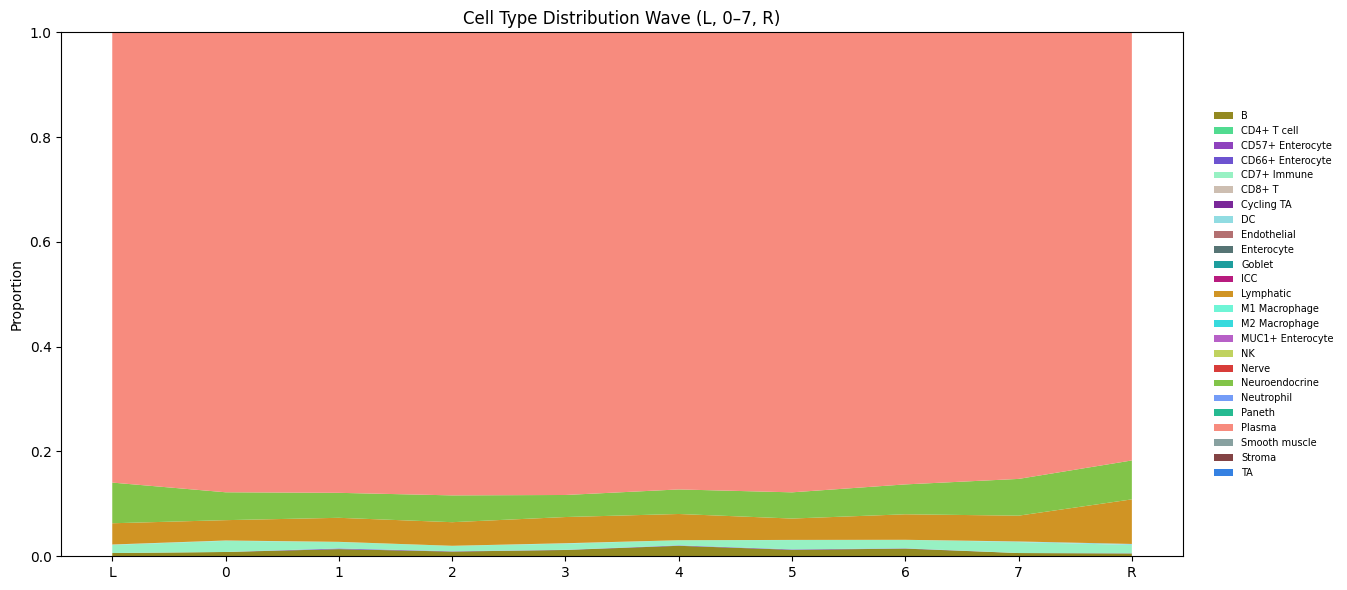

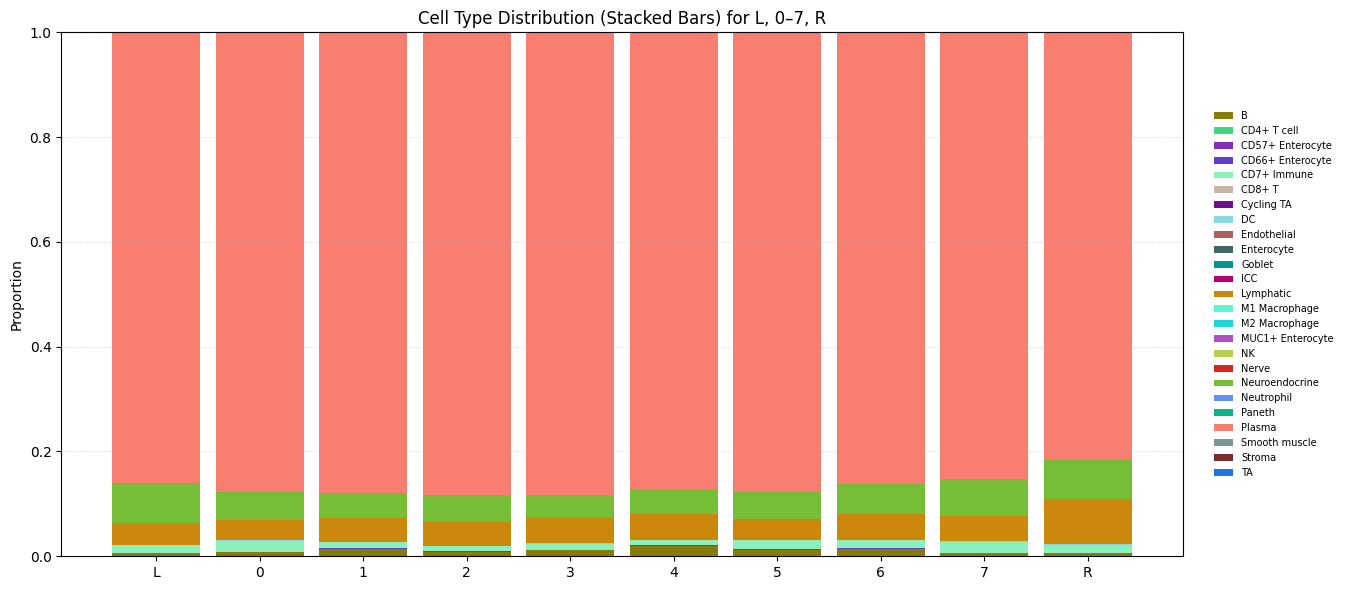

Saved:
  /content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/distribution_wave.png
  /content/drive/MyDrive/DISCO_USECASES/202509GapFillerOldResults/20251001pair_2_4_leftright_1200old_SPLIT/distribution_stacked_bars.png


In [25]:

if __name__ == "__main__":
    main()
